# Seasonal Agriculture Performance Analysis

## Objective
Analyze how agricultural performance changes across seasons, identify important patterns and relationships, and provide evidence-based recommendations.

**Dataset:** 4,000 farm records with 28 columns covering location, crop, season, environmental conditions, resource use, production, and economic performance.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()

Shape: (4000, 28)

Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## Data Cleaning
Only three columns contain missing values. Missing numeric values are filled with the **median within the same season** to preserve seasonal differences.

In [2]:
df_clean = df.copy()

for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df_clean[col] = df_clean.groupby('Season')[col].transform(
        lambda x: x.fillna(x.median())
    )

print('Remaining missing values:', df_clean.isnull().sum().sum())
print('Duplicate rows:', df_clean.duplicated().sum())

Remaining missing values: 0
Duplicate rows: 0


## 1. How does agricultural performance vary across seasons?

In [3]:
season_summary = df_clean.groupby('Season').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Rainfall=('Rainfall_mm', 'mean'),
    Avg_Temperature=('Avg_Temperature_C', 'mean'),
    Avg_Pest_Risk=('Disease_Pest_Risk_pct', 'mean')
).round(2)

season_summary

,Avg_Yield,Avg_Production,Avg_Profit,Avg_Revenue,Avg_Water_Used,Avg_Water_Efficiency,Avg_Rainfall,Avg_Temperature,Avg_Pest_Risk
Season,,,,,,,,,
Kharif,5.63,46.31,178914.65,710719.06,6102.20,5.89,852.11,28.45,54.47
Rabi,5.04,41.49,87689.47,601526.05,5846.99,5.19,435.94,23.49,40.48
Zaid,4.64,38.89,-24804.82,519171.90,6419.89,4.41,299.12,31.04,38.22


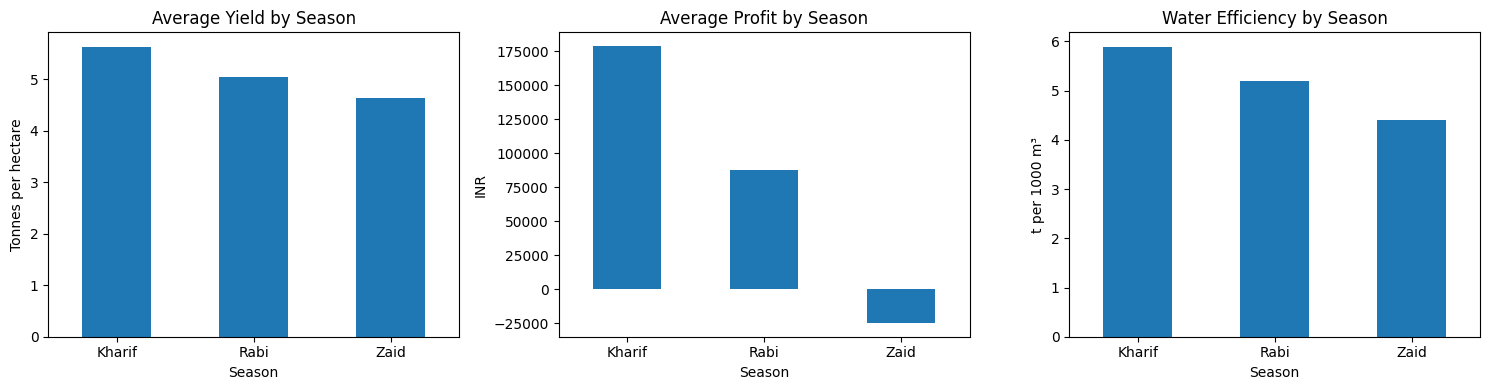

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

season_summary['Avg_Yield'].plot(kind='bar', ax=axes[0], title='Average Yield by Season')
axes[0].set_ylabel('Tonnes per hectare')
axes[0].tick_params(axis='x', rotation=0)

season_summary['Avg_Profit'].plot(kind='bar', ax=axes[1], title='Average Profit by Season')
axes[1].set_ylabel('INR')
axes[1].tick_params(axis='x', rotation=0)

season_summary['Avg_Water_Efficiency'].plot(kind='bar', ax=axes[2], title='Water Efficiency by Season')
axes[2].set_ylabel('t per 1000 m³')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Key finding
Kharif has the highest average yield, production, profit, and water efficiency. Zaid has the lowest yield and average profit is negative, making it the weakest season economically in this dataset.

## 2. Which crops perform differently across seasons?

Avg_Yield  Avg_Profit
Season Crop                            
Kharif Chilli          1.73   954380.42
       Cotton          1.38   216999.55
       Groundnut       1.49   108265.44
       Maize           2.97   -39332.67
       Pulses          1.04    43338.90
       Rice            2.70   -64903.40
       Sugarcane      53.46  1000790.81
       Wheat           2.25  -105871.87
Rabi   Chilli          1.46   638572.50
       Cotton          1.20   107343.59
       Groundnut       1.23    10416.54
       Maize           2.60   -89133.40
       Pulses          0.88   -14309.14
       Rice            2.32   -98427.87
       Sugarcane      43.28   731612.86
       Wheat           2.06  -119954.57
Zaid   Chilli          1.19   448659.09
       Cotton          0.96   -53925.34
       Groundnut       1.04   -68872.50
       Maize           2.29  -194049.17
       Pulses          0.66  -139227.81
       Rice            1.90  -227239.34
       Sugarcane      38.42   583635.80
       Wheat           1.75  -193208.95

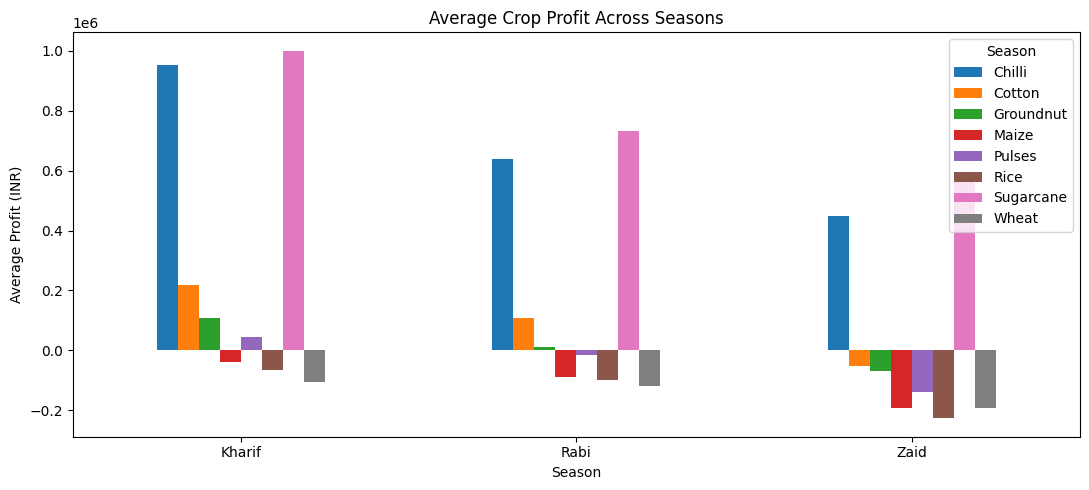

In [5]:
crop_season = df_clean.groupby(['Season', 'Crop']).agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean')
).round(2)

display(crop_season)

profit_pivot = crop_season['Avg_Profit'].unstack()
profit_pivot.plot(kind='bar', figsize=(11, 5))
plt.title('Average Crop Profit Across Seasons')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

### Key finding
Sugarcane has the highest average yield and profit in all three seasons. Several crops show declining profitability in Zaid, including maize, pulses, rice, and wheat.

## 3. What relationships exist between conditions and agricultural outcomes?

In [6]:
variables = [
    'Yield_Tonnes_Ha', 'Rainfall_mm', 'Avg_Temperature_C',
    'Soil_Moisture_pct', 'Fertilizer_kg_ha',
    'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct',
    'Profit_INR'
]

yield_corr = df_clean[variables].corr()['Yield_Tonnes_Ha'].sort_values(ascending=False).round(3)
yield_corr

Yield_Tonnes_Ha                  1.000
Water_Efficiency_t_per_1000m3    0.913
Profit_INR                       0.488
Rainfall_mm                      0.029
Disease_Pest_Risk_pct            0.014
Soil_Moisture_pct                0.011
Avg_Temperature_C                0.010
Fertilizer_kg_ha                -0.000
Name: Yield_Tonnes_Ha, dtype: float64

### Key finding
Water efficiency has a very strong positive relationship with yield in this dataset. Yield also has a moderate positive relationship with profit. Rainfall, temperature, soil moisture, fertilizer use, and pest risk show weak linear relationships with yield overall.

## 4. Economic comparison and unusual pattern

In [7]:
profitability = (df_clean.assign(Profitable=df_clean['Profit_INR'] > 0)
                 .groupby('Season')['Profitable']
                 .mean()
                 .mul(100)
                 .round(1)
                 .rename('Profitable_Farms_%'))

display(profitability.to_frame())

print('Average seasonal profit:')
print(season_summary['Avg_Profit'])

,Profitable_Farms_%
Season,
Kharif,57.8
Rabi,48.9
Zaid,35.5


Average seasonal profit:
Season
Kharif    178914.65
Rabi       87689.47
Zaid      -24804.82
Name: Avg_Profit, dtype: float64


## 5. Investigate Zaid-season costs, crop selection, and water use

This analysis identifies which crops contribute to weak Zaid-season profitability and compares their average cost and water use.

In [8]:
zaid_analysis = (df_clean[df_clean['Season'] == 'Zaid']
                 .groupby('Crop')
                 .agg(
                     Avg_Cost=('Total_Cost_INR', 'mean'),
                     Avg_Water=('Water_Used_m3', 'mean'),
                     Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
                     Avg_Profit=('Profit_INR', 'mean')
                 )
                 .sort_values('Avg_Profit'))

zaid_analysis.round(2)

,Avg_Cost,Avg_Water,Avg_Yield,Avg_Profit
Crop,,,,
Rice,559383.73,11502.52,1.90,-227239.34
Maize,576880.46,4404.45,2.29,-194049.17
Wheat,526474.11,3926.02,1.75,-193208.95
Pulses,490837.11,2647.19,0.66,-139227.81
Groundnut,549669.07,3792.30,1.04,-68872.50
Cotton,523389.25,5385.88,0.96,-53925.34
Chilli,545770.45,4986.30,1.19,448659.09
Sugarcane,581600.55,14763.53,38.42,583635.80


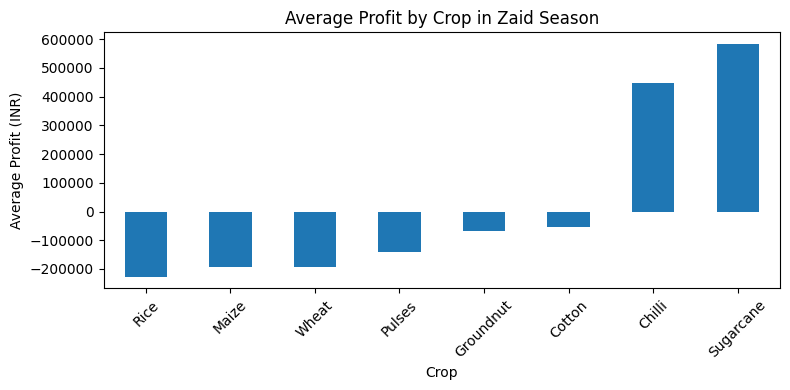

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
zaid_analysis['Avg_Profit'].plot(kind='bar', ax=ax)
ax.set_title('Average Profit by Crop in Zaid Season')
ax.set_ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Result:** Rice, Maize, Wheat and Pulses show the largest average losses in Zaid. Sugarcane and Chilli are profitable. Zaid crop planning should therefore review high-loss crops together with their costs and water requirements before expanding production.

## 6. Focus on improving water-use efficiency

The recommendation is tested by measuring the relationship between water efficiency and agricultural yield.

In [10]:
water_relationship = df_clean[[
    'Water_Efficiency_t_per_1000m3',
    'Yield_Tonnes_Ha',
    'Water_Used_m3',
    'Profit_INR'
]].corr()

water_relationship.round(3)

,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha,Water_Used_m3,Profit_INR
Water_Efficiency_t_per_1000m3,1.000,0.913,0.217,0.489
Yield_Tonnes_Ha,0.913,1.000,0.386,0.488
Water_Used_m3,0.217,0.386,1.000,0.190
Profit_INR,0.489,0.488,0.190,1.000


**Result:** Water efficiency and yield have a correlation of about **0.913**, confirming a very strong positive relationship in this dataset. Improving water-use efficiency is therefore supported by the analysis, although correlation alone does not prove causation.

## 7. Review low-profit crops separately by season

Instead of treating a crop as universally good or bad, profitability is compared for every Season–Crop combination.

In [11]:
season_crop_profit = (df_clean.groupby(['Season', 'Crop'])
                      .agg(
                          Avg_Profit=('Profit_INR', 'mean'),
                          Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
                          Avg_Cost=('Total_Cost_INR', 'mean')
                      )
                      .sort_values('Avg_Profit'))

print('Lowest-profit Season–Crop combinations:')
display(season_crop_profit.head(10).round(2))

Lowest-profit Season–Crop combinations:


Avg_Profit  Avg_Yield   Avg_Cost
Season Crop                                       
Zaid   Rice       -227239.34       1.90  559383.73
       Maize      -194049.17       2.29  576880.46
       Wheat      -193208.95       1.75  526474.11
       Pulses     -139227.81       0.66  490837.11
Rabi   Wheat      -119954.57       2.06  505232.40
Kharif Wheat      -105871.87       2.25  537467.81
Rabi   Rice        -98427.87       2.32  478246.57
       Maize       -89133.40       2.60  543861.44
Zaid   Groundnut   -68872.50       1.04  549669.07
Kharif Rice        -64903.40       2.70  556449.51

**Result:** Several crops that have losses in one season may perform differently in another. Crop decisions should therefore be based on **season-specific profitability**, yield, and cost rather than crop averages alone.

## 8. Use seasonal comparisons instead of one overall average

The final comparison keeps seasonal results separate so that planning decisions can use the differences visible in the data.

In [12]:
season_planning_summary = df_clean.groupby('Season').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
)

season_planning_summary.round(2)

,Avg_Yield,Avg_Production,Avg_Profit,Avg_Water_Efficiency
Season,,,,
Kharif,5.63,46.31,178914.65,5.89
Rabi,5.04,41.49,87689.47,5.19
Zaid,4.64,38.89,-24804.82,4.41


## Final Conclusions

### Conclusions
- **Kharif** has the strongest average performance in yield, production, profit, and water efficiency.
- **Zaid** has the weakest average performance and a negative average profit.
- **Water efficiency** has a strong positive relationship with yield.
- Agricultural performance differs by both **season and crop**, so one overall average can hide important differences.
- **Review Zaid-season crop plans before expansion.** Prioritize investigation of high-loss crops such as Rice, Maize, Wheat and Pulses, including their costs and water requirements.
- **Improve water-use efficiency.** The dataset shows a strong positive relationship between water efficiency and yield.
- **Make crop decisions separately for each season.** Review low-profit Season–Crop combinations before allocating land and resources.
- **Use seasonal performance dashboards or summaries for planning.** Compare yield, production, profit and water efficiency by season instead of relying on one overall average.

